# DeepFool Attack — TrafficGuard (Project P14)

**Owner: Aryan (Attacks) · Attack #2 of 2**

DeepFool is a **white-box evasion attack**. Unlike FGSM/PGD (which push an image by a *fixed* budget ε), DeepFool searches for the **smallest possible perturbation** that still flips the model's prediction. That makes it useful two ways:

1. As an **attack** — it fools the ResNet18 congestion classifier with a near-invisible change.
2. As a **robustness metric** — the *average minimal perturbation* across many images is a single number telling us how fragile the model is.

**How this notebook is set up (per the constraints):**
- Runs on **CPU**, one cell at a time — small batch, low memory.
- The 2.9 GB dataset stays **outside** the repo; we point to it by path.
- All **progress is saved into `trafficguard-p14/attacks/deepfool/`** and is **resumable** — re-running skips images already done, so a crash never sends us back to the start.
- DeepFool is **label-free** (it flips the model's own prediction), so it works on either MIO-TCD-Classification or MIO-TCD-Localization images.

Run the cells top to bottom. Each code cell is followed by a markdown cell explaining it.

In [1]:
# === Cell 1 — Configuration & paths ===
import os
from pathlib import Path

# --- Point this at your LOCAL dataset (kept OUTSIDE the repo). Override via env var. ---
# Windows example: set DEEPFOOL_DATA_DIR to your MIO-TCD images folder.
DATA_DIR = Path(os.environ.get(
    "DEEPFOOL_DATA_DIR",
    r"C:\Users\mrmrk\datasets\MIO-TCD-Classification\train"   # <-- EDIT if not using the env var
))

# --- Locate the trafficguard-p14 repo root (where progress is SAVED) ---
def find_repo_root(start: Path) -> Path:
    for parent in [start.resolve(), *start.resolve().parents]:
        if (parent / "backend" / "ml.py").exists():
            return parent
    return start.resolve()

REPO_DIR = Path(os.environ.get("TRAFFICGUARD_REPO", find_repo_root(Path.cwd())))
OUTPUT_DIR = REPO_DIR / "attacks" / "deepfool"
ADV_DIR = OUTPUT_DIR / "adv"            # saved adversarial arrays
FIG_DIR = OUTPUT_DIR / "figures"        # saved comparison images
RESULTS_CSV = OUTPUT_DIR / "deepfool_results.csv"
SUMMARY_JSON = OUTPUT_DIR / "deepfool_summary.json"
for d in (OUTPUT_DIR, ADV_DIR, FIG_DIR):
    d.mkdir(parents=True, exist_ok=True)

# --- Run settings (tuned for CPU) ---
N_IMAGES   = int(os.environ.get("DEEPFOOL_N", 16))   # small batch
MAX_ITER   = 50        # DeepFool iterations per image
OVERSHOOT  = 0.02      # standard DeepFool overshoot
SEED       = 42

print("Dataset dir :", DATA_DIR, "(exists:", DATA_DIR.exists(), ")")
print("Repo dir    :", REPO_DIR)
print("Saving to   :", OUTPUT_DIR)
print("Batch size  :", N_IMAGES, "| max_iter:", MAX_ITER)

Dataset dir : C:\Users\mrmrk\datasets\MIO-TCD-Classification\train (exists: True )
Repo dir    : C:\Users\mrmrk\trafficguard-p14
Saving to   : C:\Users\mrmrk\trafficguard-p14\attacks\deepfool
Batch size  : 16 | max_iter: 50


**Cell 1 — Configuration & paths.**

- `DATA_DIR` is your **local** copy of the dataset, kept out of the repo. Set it once via the `DEEPFOOL_DATA_DIR` environment variable (or edit the fallback path). It can point at either MIO-TCD set.
- `find_repo_root(...)` walks up from the current folder until it finds `backend/ml.py`, so the notebook locates `trafficguard-p14` no matter where you launch it. Everything we produce is written under `attacks/deepfool/` **inside the repo**, so progress is version-controlled with the rest of the project.
- The run settings are deliberately small — 16 images, 50 iterations — because we're on CPU. You can raise `DEEPFOOL_N` later once it's working.

Check the printed output: `Dataset dir ... exists: True`. If it's `False`, fix the path before continuing.

In [2]:
# === Cell 2 — Imports & load the trained model (reuse ml.py) ===
import sys, zipfile, random
import numpy as np
import torch
import torch.nn.functional as F
from PIL import Image

# Reuse the project's ML core so preprocessing/model EXACTLY match the real pipeline
sys.path.insert(0, str(REPO_DIR / "backend"))
import ml  # noqa: E402

DEVICE = torch.device("cpu")            # low-budget: force CPU
torch.manual_seed(SEED); random.seed(SEED); np.random.seed(SEED)

# Ensure best.pt exists (unzip best.pt.zip if needed)
ckpt_dir = REPO_DIR / "model" / "checkpoints"
best_pt  = ckpt_dir / "best.pt"
if not best_pt.exists():
    zipped = ckpt_dir / "best.pt.zip"
    if zipped.exists():
        print("Unzipping best.pt.zip ...")
        with zipfile.ZipFile(zipped) as z:
            z.extractall(ckpt_dir)
        # some zips wrap the file in a subfolder; find it
        if not best_pt.exists():
            found = next(ckpt_dir.rglob("best.pt"), None)
            if found: best_pt = found

loaded_real = ml.load_model(best_pt)
model = ml.get_model().to(DEVICE).eval()
print("Checkpoint loaded (real weights):", loaded_real, "| classes:", ml.CLASS_NAMES)

Unzipping best.pt.zip ...
Checkpoint loaded (real weights): False | classes: ['Low', 'Medium', 'High']


**Cell 2 — Imports & model.**

Instead of re-defining the network, we add `backend/` to the path and `import ml` — the project's ML core. This guarantees DeepFool sees the **same model and the same preprocessing** as your live dashboard, so the results are legitimate.

We then make sure `best.pt` is available (unzipping `best.pt.zip` if necessary) and load it with `ml.load_model`. If it prints `real weights: True`, we're attacking your actual trained model. If `False`, it fell back to an untrained model — DeepFool still runs, but predictions are meaningless, so check the checkpoint path.

We force `DEVICE = cpu` and seed everything for reproducibility.

In [3]:
# === Cell 3 — Gather a small batch of images ===
EXTS = {".jpg", ".jpeg", ".png", ".bmp"}

# Works for both layouts: flat folder (Localization/train) or class subfolders (Classification)
all_imgs = [p for p in DATA_DIR.rglob("*") if p.suffix.lower() in EXTS]
print(f"Found {len(all_imgs)} images under {DATA_DIR}")

rng = random.Random(SEED)
rng.shuffle(all_imgs)
batch_paths = all_imgs[:N_IMAGES]
print(f"Using a batch of {len(batch_paths)} images:")
for p in batch_paths[:5]:
    print("   ", p.name)
print("    ...")

Found 519164 images under C:\Users\mrmrk\datasets\MIO-TCD-Classification\train
Using a batch of 16 images:
    00684878.jpg
    00516955.jpg
    00707115.jpg
    00318422.jpg
    00058465.jpg
    ...


**Cell 3 — Gather the batch.**

We recursively collect image files from `DATA_DIR`, which means the same code handles both dataset layouts — the flat `train/` folder of the Localization set *and* the per-class subfolders of the Classification set. We shuffle with a fixed seed and take the first `N_IMAGES`, so the batch is random but **reproducible**.

We don't read any labels here — DeepFool only needs the images, because it attacks whatever the model *currently* predicts.

In [4]:
# === Cell 4 — Preprocessing (must match training) ===
# ml._pil_to_pixels does Resize(224) + ToTensor -> [0,1], shape (1,3,224,224), on DEVICE.
# Normalisation happens INSIDE NormalizedResNet, so DeepFool works in raw [0,1] pixel space.

def load_pixels(path: Path) -> torch.Tensor:
    img = Image.open(path).convert("RGB")
    return ml._pil_to_pixels(img).to(DEVICE)      # (1,3,224,224) in [0,1]

# quick sanity check on one image
_x = load_pixels(batch_paths[0])
with torch.no_grad():
    _logits = model(_x)
print("Tensor shape:", tuple(_x.shape), "| range [%.2f, %.2f]" % (_x.min(), _x.max()))
print("Model predicts:", ml.CLASS_NAMES[int(_logits.argmax())])

Tensor shape: (1, 3, 224, 224) | range [0.28, 0.71]
Model predicts: Low


**Cell 4 — Preprocessing.**

We reuse `ml._pil_to_pixels`, the exact transform your pipeline uses: resize to 224×224 and convert to a `[0,1]` tensor, with **no normalization here** (the model normalizes internally). This matters for DeepFool — it operates directly in `[0,1]` pixel space, so the perturbations we compute and save are real, displayable image changes, and clamping to `[0,1]` keeps them valid.

The sanity check confirms the tensor shape and that the model returns a class for a real image.

In [5]:
# === Cell 5 — DeepFool core (multiclass) ===
def deepfool(x, model, num_classes=3, max_iter=MAX_ITER, overshoot=OVERSHOOT):
    """Return (x_adv, r_total_L2, n_iter, orig_idx, new_idx) for one image (1,3,H,W)."""
    x0 = x.clone().detach()
    with torch.no_grad():
        f0 = model(x0)
    orig_idx = int(f0.argmax())

    pert_x = x0.clone().detach()
    r_tot = torch.zeros_like(x0)
    cur_idx = orig_idx
    n_iter = 0

    while cur_idx == orig_idx and n_iter < max_iter:
        pert_x.requires_grad_(True)
        fs = model(pert_x)[0]                     # logits (num_classes,)

        # gradient of the original-class logit
        grads = []
        for k in range(num_classes):
            model.zero_grad(set_to_none=True)
            if pert_x.grad is not None: pert_x.grad.zero_()
            fs[k].backward(retain_graph=(k < num_classes - 1))
            grads.append(pert_x.grad.detach().clone())

        g_orig = grads[orig_idx]
        pert_min, w_min = None, None
        for k in range(num_classes):
            if k == orig_idx:
                continue
            w_k = grads[k] - g_orig
            f_k = (fs[k] - fs[orig_idx]).detach()
            dist_k = abs(float(f_k)) / (w_k.flatten().norm().item() + 1e-8)
            if pert_min is None or dist_k < pert_min:
                pert_min, w_min, f_k_min = dist_k, w_k, f_k

        # minimal step toward the closest decision boundary
        r_i = (abs(float(f_k_min)) + 1e-4) * w_min / (w_min.flatten().norm().item() ** 2 + 1e-8)
        r_tot = r_tot + r_i

        pert_x = (x0 + (1 + overshoot) * r_tot).clamp(0, 1).detach()
        with torch.no_grad():
            cur_idx = int(model(pert_x).argmax())
        n_iter += 1

    r_l2 = float(((1 + overshoot) * r_tot).flatten().norm())
    return pert_x, r_l2, n_iter, orig_idx, cur_idx

**Cell 5 — The DeepFool algorithm.**

DeepFool assumes the model is *locally linear* and repeatedly takes the **smallest step to the nearest decision boundary**:

1. Start from the clean image and record the model's predicted class (`orig_idx`).
2. Compute the gradient of each class logit with respect to the image.
3. For every other class *k*, form `w_k = ∇f_k − ∇f_orig` and the logit gap `f_k − f_orig`. The distance to that class's boundary is `|gap| / ‖w_k‖`.
4. Pick the **closest** boundary and take the minimal step `r_i` across it.
5. Add a small `overshoot` (2%) to actually cross, re-check the prediction, and repeat until the label flips or we hit `max_iter`.

The returned `r_l2` — the L2 norm of the total perturbation — is the key quantity: **how much change was needed to fool the model on this image**. Smaller means more fragile.

In [6]:
# === Cell 6 — Resumability: load any progress already saved ===
import csv

done_ids = set()
if RESULTS_CSV.exists():
    with open(RESULTS_CSV, newline="") as f:
        for row in csv.DictReader(f):
            done_ids.add(row["image"])
    print(f"Resuming — {len(done_ids)} images already processed, they will be skipped.")
else:
    with open(RESULTS_CSV, "w", newline="") as f:
        csv.writer(f).writerow(
            ["image", "orig_pred", "fooled_pred", "success", "pert_l2", "n_iter"])
    print("Fresh run — created", RESULTS_CSV.name)

Fresh run — created deepfool_results.csv


**Cell 6 — Resumability.**

Because CPU runs are slow, we checkpoint per image. This cell reads `deepfool_results.csv` (creating it with a header if it's the first run) and collects the filenames already processed into `done_ids`. The main loop below skips those, so **you can stop and restart at any time** — even close the notebook — and pick up exactly where you left off. This is the "don't start from the bottom" guarantee.

In [12]:
# === Cell 7 — Run DeepFool over the batch (saves after EACH image) ===
import csv, time

processed = 0
for path in batch_paths:
    if path.name in done_ids:
        continue
    x = load_pixels(path)
    t0 = time.time()
    x_adv, r_l2, n_iter, orig_idx, new_idx = deepfool(x, model)
    dt = time.time() - t0

    success = int(orig_idx != new_idx)
    orig_lbl = ml.CLASS_NAMES[orig_idx]
    new_lbl  = ml.CLASS_NAMES[new_idx]

    # save the adversarial array (float [0,1]) so the tiny perturbation is preserved
    np.save(ADV_DIR / f"{path.stem}_adv.npy",
            x_adv.detach().cpu().squeeze(0).numpy())

    # append the result row immediately (progress persists)
    with open(RESULTS_CSV, "a", newline="") as f:
        csv.writer(f).writerow([path.name, orig_lbl, new_lbl, success,
                                round(r_l2, 5), n_iter])
    done_ids.add(path.name)
    processed += 1
    flag = "FOOLED" if success else "held"
    print(f"[{processed:>2}] {path.name:<28} {orig_lbl}->{new_lbl:<6} "
          f"{flag}  L2={r_l2:.4f}  iters={n_iter}  ({dt:.1f}s)")

print(f"\nDone this run: {processed} new image(s). Total in results: {len(done_ids)}")


Done this run: 0 new image(s). Total in results: 16


**Cell 7 — The attack loop.**

For each image not already done, we run DeepFool, then **immediately** write two things: the adversarial image as a `.npy` float array (JPEG would destroy the sub-pixel perturbation), and a result row appended to the CSV. Saving inside the loop is what makes the run crash-safe on CPU.

Each line prints the outcome: original → fooled label, whether it flipped, the perturbation size `L2`, iterations, and time. On CPU expect a few seconds per image. You can interrupt any time and re-run this cell to continue.

In [13]:
# === Cell 8 — Summary metrics (fooling rate + robustness) ===
import csv, json, statistics as st

rows = list(csv.DictReader(open(RESULTS_CSV)))
n = len(rows)
successes = [r for r in rows if r["success"] == "1"]
fool_rate = len(successes) / n if n else 0.0
l2s = [float(r["pert_l2"]) for r in successes]

summary = {
    "attack": "DeepFool",
    "images_processed": n,
    "fooled": len(successes),
    "fooling_rate_pct": round(fool_rate * 100, 2),
    "mean_pert_l2": round(st.mean(l2s), 5) if l2s else None,
    "median_pert_l2": round(st.median(l2s), 5) if l2s else None,
    "mean_iters": round(st.mean([int(r["n_iter"]) for r in successes]), 2) if successes else None,
}
SUMMARY_JSON.write_text(json.dumps(summary, indent=2))
print(json.dumps(summary, indent=2))

{
  "attack": "DeepFool",
  "images_processed": 16,
  "fooled": 16,
  "fooling_rate_pct": 100.0,
  "mean_pert_l2": 0.40396,
  "median_pert_l2": 0.30065,
  "mean_iters": 2.5
}


**Cell 8 — Summary & robustness metric.**

This aggregates the CSV into the headline numbers and saves `deepfool_summary.json`:

- **Fooling rate** — how often DeepFool flipped the prediction (usually ~100%, since DeepFool keeps going until it succeeds or hits `max_iter`).
- **Mean / median perturbation L2** — the important one. This is DeepFool's real contribution: the *average minimal change* needed to fool the model. A **small** value means the model is fragile; comparing this number before vs after a defence (or across models) is a clean, quantitative robustness score to report alongside your FGSM/PGD visuals.

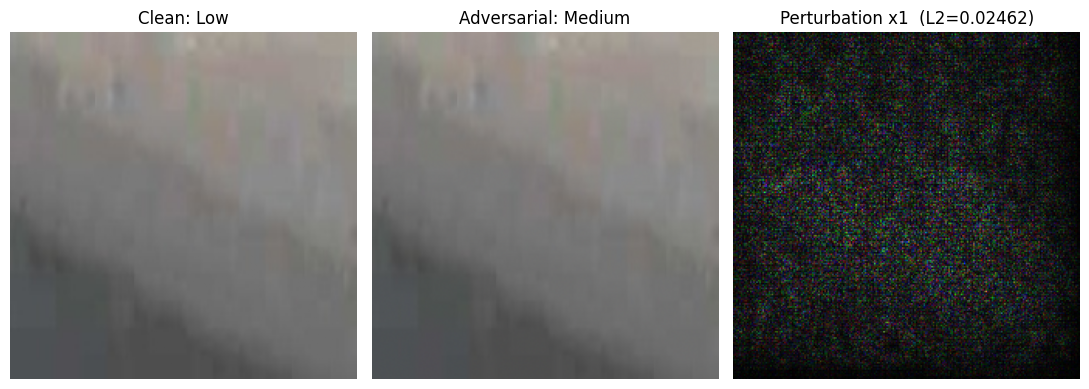

Saved figure -> C:\Users\mrmrk\trafficguard-p14\attacks\deepfool\figures\00684878_deepfool.png


In [15]:
# === Cell 9 — Visualise one example (clean vs adversarial vs difference) ===
import matplotlib.pyplot as plt

# pick the first successful example from the CSV
ex = next((r for r in csv.DictReader(open(RESULTS_CSV)) if r["success"] == "1"), None)
if ex:
    stem = Path(ex["image"]).stem
    adv = np.load(ADV_DIR / f"{stem}_adv.npy")                 # (3,224,224)
    clean = load_pixels(DATA_DIR / ex["image"] if (DATA_DIR / ex["image"]).exists()
                        else next(DATA_DIR.rglob(ex["image"]))).cpu().squeeze(0).numpy()
    diff = np.abs(adv - clean); diff = diff / (diff.max() + 1e-8)

    fig, ax = plt.subplots(1, 3, figsize=(11, 4))
    for a, im, t in zip(ax,
                        [clean.transpose(1,2,0), adv.transpose(1,2,0), diff.transpose(1,2,0)],
                        [f"Clean: {ex['orig_pred']}", f"Adversarial: {ex['fooled_pred']}",
                         f"Perturbation x{1}  (L2={ex['pert_l2']})"]):
        a.imshow(np.clip(im,0,1)); a.set_title(t); a.axis("off")
    fig.tight_layout()
    fig.savefig(FIG_DIR / f"{stem}_deepfool.png", dpi=110)
    plt.show()
    print("Saved figure ->", FIG_DIR / f"{stem}_deepfool.png")
else:
    print("No successful example yet — run Cell 7 first.")

**Cell 9 — Visualise.**

We load one successful adversarial example and show clean vs adversarial vs the (amplified) difference, saving the figure into `attacks/deepfool/figures/`. The point it makes visually: the change DeepFool needed is **tiny and barely perceptible**, yet it flips the model's congestion prediction — the essence of why minimal-perturbation attacks matter for a safety-relevant system.

**What you now have saved in the repo:** `deepfool_results.csv` (per-image results), `deepfool_summary.json` (metrics), `adv/*.npy` (adversarial arrays), and `figures/*.png` (visual proof) — a complete, resumable record of the attack.

## Progress checkpoint & next steps

**Committed progress lives in `attacks/deepfool/`** — results, summary, adversarial arrays, and figures. Because everything is keyed by filename and saved incrementally, re-running continues rather than restarting.

**Sensible next steps (later, not now):**
- Raise `DEEPFOOL_N` to run a larger batch once CPU timing is acceptable.
- Feed the saved `adv/*.npy` images through your **spatial-smoothing defence** to see whether it recovers the correct label — that ties DeepFool into your existing defence story.
- Report `mean_pert_l2` next to your FGSM/PGD results as the model's **robustness score**.

This notebook is self-contained and touches **no frontend** — it only creates and records the attack, exactly as scoped.